In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("Fuel_Consumption_2000-2022.csv")

print("Rows and columns:", df.shape)
display(df.head())

Rows and columns: (22556, 13)


,YEAR,MAKE,MODEL,VEHICLE CLASS,ENGINE SIZE,CYLINDERS,TRANSMISSION,FUEL,FUEL CONSUMPTION,HWY (L/100 km),COMB (L/100 km),COMB (mpg),EMISSIONS
0,2000,ACURA,1.6EL,COMPACT,1.6,4,A4,X,9.2,6.7,8.1,35,186
1,2000,ACURA,1.6EL,COMPACT,1.6,4,M5,X,8.5,6.5,7.6,37,175
2,2000,ACURA,3.2TL,MID-SIZE,3.2,6,AS5,Z,12.2,7.4,10.0,28,230
3,2000,ACURA,3.5RL,MID-SIZE,3.5,6,A4,Z,13.4,9.2,11.5,25,264
4,2000,ACURA,INTEGRA,SUBCOMPACT,1.8,4,A4,X,10.0,7.0,8.6,33,198


## 2. Data Quality Checks
Check column types, missing values, duplicate records and inconsistent category labels before cleaning.

In [73]:
# Check column names and data types
df.info()

# Count missing values
print("\nMissing values per column:")
print(df.isna().sum())

# Count exact duplicate records
print("\nExact duplicate rows:", df.duplicated().sum())

# Display all copies of duplicated records
display(df[df.duplicated(keep=False)])

# Inspect labels for inconsistent formatting
print("\nManufacturer labels:")
print(sorted(df["MAKE"].unique()))

print("\nVehicle class labels:")
print(sorted(df["VEHICLE CLASS"].unique()))

<class 'pandas.DataFrame'>
RangeIndex: 22556 entries, 0 to 22555
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   YEAR              22556 non-null  int64  
 1   MAKE              22556 non-null  str    
 2   MODEL             22556 non-null  str    
 3   VEHICLE CLASS     22556 non-null  str    
 4   ENGINE SIZE       22556 non-null  float64
 5   CYLINDERS         22556 non-null  int64  
 6   TRANSMISSION      22556 non-null  str    
 7   FUEL              22556 non-null  str    
 8   FUEL CONSUMPTION  22556 non-null  float64
 9   HWY (L/100 km)    22556 non-null  float64
 10  COMB (L/100 km)   22556 non-null  float64
 11  COMB (mpg)        22556 non-null  int64  
 12  EMISSIONS         22556 non-null  int64  
dtypes: float64(4), int64(4), str(5)
memory usage: 2.2 MB

Missing values per column:
YEAR                0
MAKE                0
MODEL               0
VEHICLE CLASS       0
ENGINE SIZE         0
C

,YEAR,MAKE,MODEL,VEHICLE CLASS,ENGINE SIZE,CYLINDERS,TRANSMISSION,FUEL,FUEL CONSUMPTION,HWY (L/100 km),COMB (L/100 km),COMB (mpg),EMISSIONS
377,2000,LAND ROVER,DISCOVERY SERIES II 4X4,SUV,4.0,8,A4,Z,17.7,12.7,15.4,18,354
378,2000,LAND ROVER,DISCOVERY SERIES II 4X4,SUV,4.0,8,A4,Z,17.7,12.7,15.4,18,354



Manufacturer labels:
['ACURA', 'ALFA ROMEO', 'ASTON MARTIN', 'AUDI', 'Acura', 'Alfa Romeo', 'Aston Martin', 'Audi', 'BENTLEY', 'BMW', 'BUGATTI', 'BUICK', 'Bentley', 'Bugatti', 'Buick', 'CADILLAC', 'CHEVROLET', 'CHRYSLER', 'Cadillac', 'Chevrolet', 'Chrysler', 'DAEWOO', 'DODGE', 'Dodge', 'FERRARI', 'FIAT', 'FORD', 'Ford', 'GENESIS', 'GMC', 'Genesis', 'HONDA', 'HUMMER', 'HYUNDAI', 'Honda', 'Hyundai', 'INFINITI', 'ISUZU', 'Infiniti', 'JAGUAR', 'JEEP', 'Jaguar', 'Jeep', 'KIA', 'Kia', 'LAMBORGHINI', 'LAND ROVER', 'LEXUS', 'LINCOLN', 'Lamborghini', 'Land Rover', 'Lexus', 'Lincoln', 'MASERATI', 'MAZDA', 'MERCEDES-BENZ', 'MINI', 'MITSUBISHI', 'Maserati', 'Mazda', 'Mercedes-Benz', 'Mitsubishi', 'NISSAN', 'Nissan', 'OLDSMOBILE', 'PLYMOUTH', 'PONTIAC', 'PORSCHE', 'Porsche', 'RAM', 'ROLLS-ROYCE', 'Ram', 'Rolls-Royce', 'SAAB', 'SATURN', 'SCION', 'SMART', 'SRT', 'SUBARU', 'SUZUKI', 'Subaru', 'TOYOTA', 'Toyota', 'VOLKSWAGEN', 'VOLVO', 'Volkswagen', 'Volvo']

Vehicle class labels:
['COMPACT', 'Compact

## 3. Data Cleaning
Create a separate working copy, remove exact duplicates, and standardize category labels.

In [74]:
# Preserve the original DataFrame
df_clean = df.copy()

# Remove exact duplicate rows
rows_before = len(df_clean)
df_clean = df_clean.drop_duplicates().reset_index(drop=True)

print("Duplicates removed:", rows_before - len(df_clean))

# Standardize capitalization and remove surrounding spaces
for column in ["MAKE", "MODEL", "VEHICLE CLASS", "TRANSMISSION", "FUEL"]:
    df_clean[column] = df_clean[column].str.strip().str.upper()

# Standardize punctuation in vehicle class labels
# Example: "SUV: SMALL" becomes "SUV - SMALL"
df_clean["VEHICLE CLASS"] = (
    df_clean["VEHICLE CLASS"]
    .str.replace(r"\s*:\s*", " - ", regex=True)
    .str.replace(r"\s+", " ", regex=True)
)

print("Rows after removing the exact duplicate:", len(df_clean))

print("\nMissing values in every column:")
print(df_clean.isna().sum().to_string())

print("\nStandardized vehicle classes:")
print(sorted(df_clean["VEHICLE CLASS"].unique()))

Duplicates removed: 1
Rows after removing the exact duplicate: 22555

Missing values in every column:
YEAR                0
MAKE                0
MODEL               0
VEHICLE CLASS       0
ENGINE SIZE         0
CYLINDERS           0
TRANSMISSION        0
FUEL                0
FUEL CONSUMPTION    0
HWY (L/100 km)      0
COMB (L/100 km)     0
COMB (mpg)          0
EMISSIONS           0

Standardized vehicle classes:
['COMPACT', 'FULL-SIZE', 'MID-SIZE', 'MINICOMPACT', 'MINIVAN', 'PICKUP TRUCK - SMALL', 'PICKUP TRUCK - STANDARD', 'SPECIAL PURPOSE VEHICLE', 'STATION WAGON - MID-SIZE', 'STATION WAGON - SMALL', 'SUBCOMPACT', 'SUV', 'SUV - SMALL', 'SUV - STANDARD', 'TWO-SEATER', 'VAN - CARGO', 'VAN - PASSENGER']


In [75]:
# Review numerical ranges
display(df_clean.describe().T)

# Basic validity checks
positive_columns = [
    "ENGINE SIZE", "CYLINDERS", "FUEL CONSUMPTION",
    "HWY (L/100 km)", "COMB (L/100 km)",
    "COMB (mpg)", "EMISSIONS"
]

invalid_counts = (df_clean[positive_columns] <= 0).sum()

print("Zero or negative values:")
print(invalid_counts.to_string())

print("\nYears outside the dataset's stated range:")
print((~df_clean["YEAR"].between(2000, 2022)).sum())

print("\nDuplicate rows after standardizing labels:")
print(df_clean.duplicated().sum())

,count,mean,std,min,25%,50%,75%,max
YEAR,22555.0,2011.554955,6.297939,2000.0,2006.0,2012.0,2017.0,2022.0
ENGINE SIZE,22555.0,3.356617,1.335448,0.8,2.3,3.0,4.2,8.4
CYLINDERS,22555.0,5.854046,1.819582,2.0,4.0,6.0,8.0,16.0
FUEL CONSUMPTION,22555.0,12.763294,3.500922,3.5,10.4,12.3,14.7,30.6
HWY (L/100 km),22555.0,8.918958,2.274675,3.2,7.3,8.4,10.2,20.9
COMB (L/100 km),22555.0,11.034148,2.910839,3.6,9.1,10.6,12.7,26.1
COMB (mpg),22555.0,27.374950,7.376881,11.0,22.0,27.0,31.0,78.0
EMISSIONS,22555.0,250.063844,59.352558,83.0,209.0,243.0,288.0,608.0


Zero or negative values:
ENGINE SIZE         0
CYLINDERS           0
FUEL CONSUMPTION    0
HWY (L/100 km)      0
COMB (L/100 km)     0
COMB (mpg)          0
EMISSIONS           0

Years outside the dataset's stated range:
0

Duplicate rows after standardizing labels:
0


In [76]:
df_clean.to_csv("Fuel_Consumption_Cleaned.csv", index=False)
print("Cleaned dataset saved.")

Cleaned dataset saved.


## 4. Descriptive Statistical Analysis
Calculate the mean, median, mode, variance and standard deviation
of engine size and combined fuel consumption.

In [77]:
columns = ["ENGINE SIZE", "COMB (L/100 km)"]

statistics = pd.DataFrame({
    "Mean": df_clean[columns].mean(),
    "Median": df_clean[columns].median(),
    "Variance": df_clean[columns].var(ddof=1),
    "Standard deviation": df_clean[columns].std(ddof=1)
})

display(statistics.round(3))

# Display every mode in case a variable has multiple modes
for column in columns:
    print(f"Mode(s) of {column}: {df_clean[column].mode().tolist()}")

,Mean,Median,Variance,Standard deviation
ENGINE SIZE,3.357,3.0,1.783,1.335
COMB (L/100 km),11.034,10.6,8.473,2.911


Mode(s) of ENGINE SIZE: [2.0]
Mode(s) of COMB (L/100 km): [9.8]


## 5. NumPy Calculations and Correlation Analysis
Use NumPy arrays to calculate fuel consumption percentiles and
Pearson correlation between engine size and combined fuel consumption.

In [78]:
# Convert the two numerical variables into NumPy arrays
engine_size = df_clean["ENGINE SIZE"].to_numpy(dtype=float)
consumption = df_clean["COMB (L/100 km)"].to_numpy(dtype=float)

# Percentiles describe the distribution of fuel consumption
percentiles = np.percentile(consumption, [25, 50, 75])

print("Combined fuel consumption percentiles (L/100 km):")
for percentile, value in zip([25, 50, 75], percentiles):
    print(f"{percentile}th percentile: {value:.2f}")

print(f"Interquartile range: {percentiles[2] - percentiles[0]:.2f} L/100 km")

# Pearson correlation measures the linear relationship
r = np.corrcoef(engine_size, consumption)[0, 1]

print(f"\nPearson correlation (r): {r:.3f}")

Combined fuel consumption percentiles (L/100 km):
25th percentile: 9.10
50th percentile: 10.60
75th percentile: 12.70
Interquartile range: 3.60 L/100 km

Pearson correlation (r): 0.807


## 6. Matplotlib Visualizations
### 6.1 Distribution of Combined Fuel Consumption

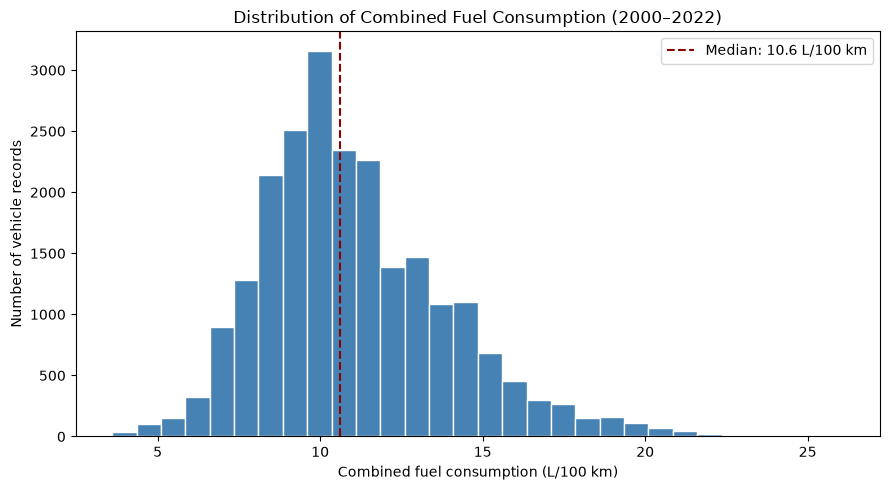

In [79]:
from pathlib import Path

# Create a folder for the figures
figures_dir = Path("figures")
figures_dir.mkdir(exist_ok=True)

fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(consumption, bins=30, color="steelblue", edgecolor="white")
ax.axvline(
    np.median(consumption),
    color="darkred",
    linestyle="--",
    label=f"Median: {np.median(consumption):.1f} L/100 km"
)

ax.set_title("Distribution of Combined Fuel Consumption (2000–2022)")
ax.set_xlabel("Combined fuel consumption (L/100 km)")
ax.set_ylabel("Number of vehicle records")
ax.legend()

fig.tight_layout()
fig.savefig(figures_dir / "01_consumption_histogram.png", dpi=300)
plt.show()

### 6.2 Engine Size and Combined Fuel Consumption

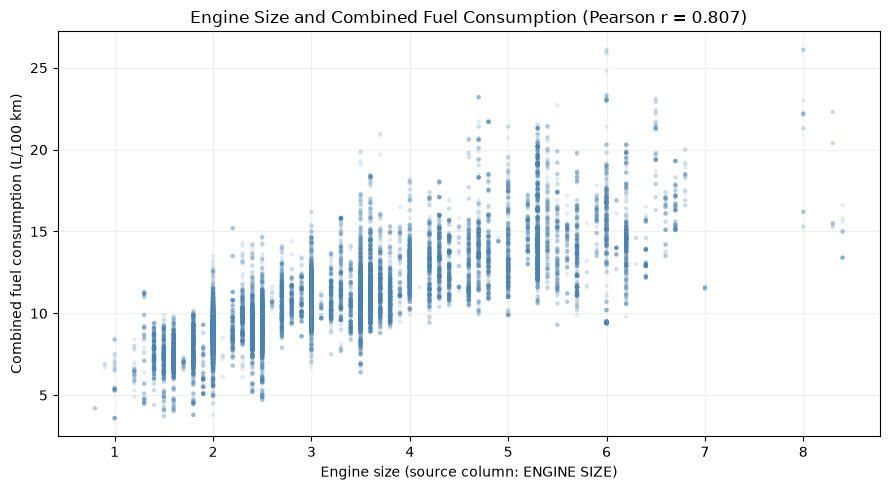

In [80]:
fig, ax = plt.subplots(figsize=(9, 5))

# Small, transparent markers help show overlapping records
ax.scatter(
    engine_size,
    consumption,
    s=10,
    alpha=0.15,
    color="steelblue",
    edgecolors="none"
)

ax.set_title(
    f"Engine Size and Combined Fuel Consumption (Pearson r = {r:.3f})"
)
ax.set_xlabel("Engine size (source column: ENGINE SIZE)")
ax.set_ylabel("Combined fuel consumption (L/100 km)")
ax.grid(alpha=0.2)

fig.tight_layout()
fig.savefig(figures_dir / "02_engine_consumption_scatter.png", dpi=300)
plt.show()

### 6.3 Fuel Consumption by Vehicle Class
Compare average consumption and variation within each vehicle class.

In [81]:
class_summary = (
    df_clean.groupby("VEHICLE CLASS")["COMB (L/100 km)"]
    .agg(
        Records="count",
        Mean="mean",
        Median="median",
        Standard_deviation="std",
        Minimum="min",
        Maximum="max"
    )
    .sort_values("Mean")
)

display(class_summary.round(2))

class_summary.to_csv("Vehicle_Class_Summary.csv")

,Records,Mean,Median,Standard_deviation,Minimum,Maximum
VEHICLE CLASS,,,,,,
STATION WAGON - SMALL,877,8.74,8.70,1.46,4.6,15.0
COMPACT,3127,9.17,9.00,2.06,3.7,17.9
MID-SIZE,2960,9.75,9.60,2.40,3.8,20.0
SUV - SMALL,1756,9.95,9.80,1.59,5.8,16.5
SUBCOMPACT,2010,10.07,9.80,2.21,3.6,22.7
STATION WAGON - MID-SIZE,387,10.08,10.00,1.57,4.5,16.5
MINICOMPACT,994,10.24,10.40,1.99,5.1,18.6
SPECIAL PURPOSE VEHICLE,114,10.51,10.40,1.57,8.0,14.7
PICKUP TRUCK - SMALL,511,11.44,11.40,1.28,6.3,15.2


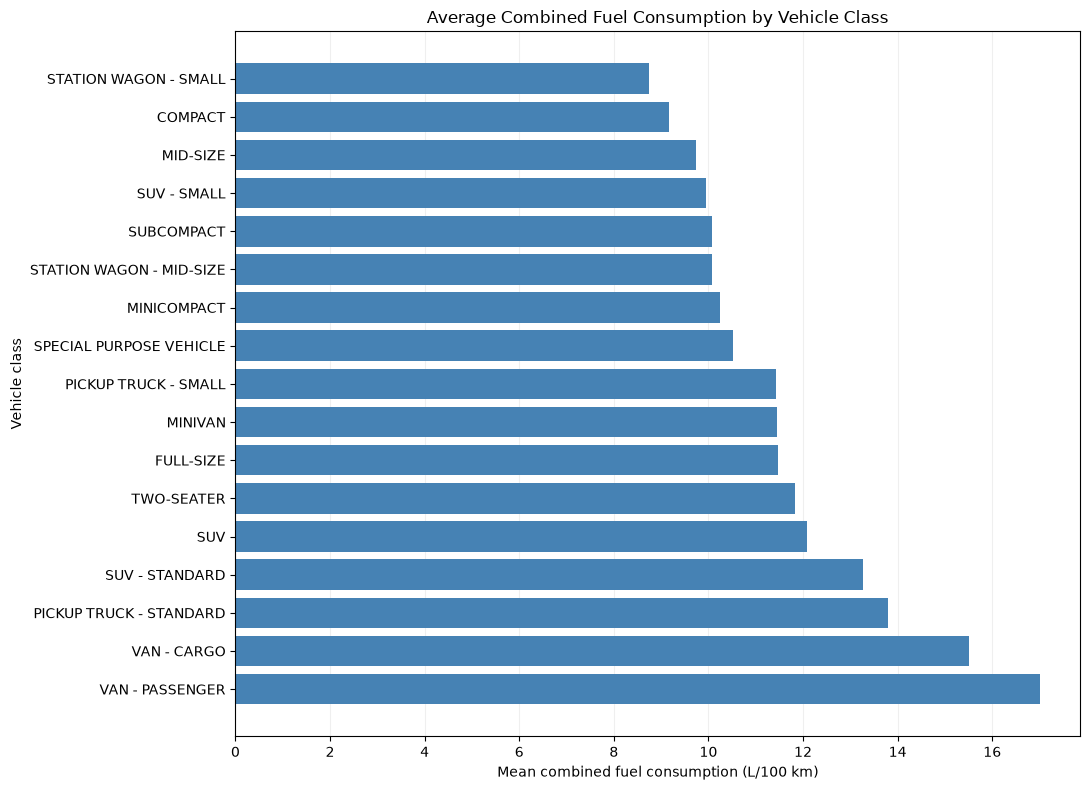

In [82]:
fig, ax = plt.subplots(figsize=(11, 8))

ax.barh(
    class_summary.index,
    class_summary["Mean"],
    color="steelblue"
)

ax.invert_yaxis()
ax.set_title("Average Combined Fuel Consumption by Vehicle Class")
ax.set_xlabel("Mean combined fuel consumption (L/100 km)")
ax.set_ylabel("Vehicle class")
ax.grid(axis="x", alpha=0.2)
ax.set_axisbelow(True)

fig.tight_layout()
fig.savefig(
    figures_dir / "03_consumption_by_class.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### 6.4 Number of Records by Vehicle Class
Check how many records support each vehicle class comparison.

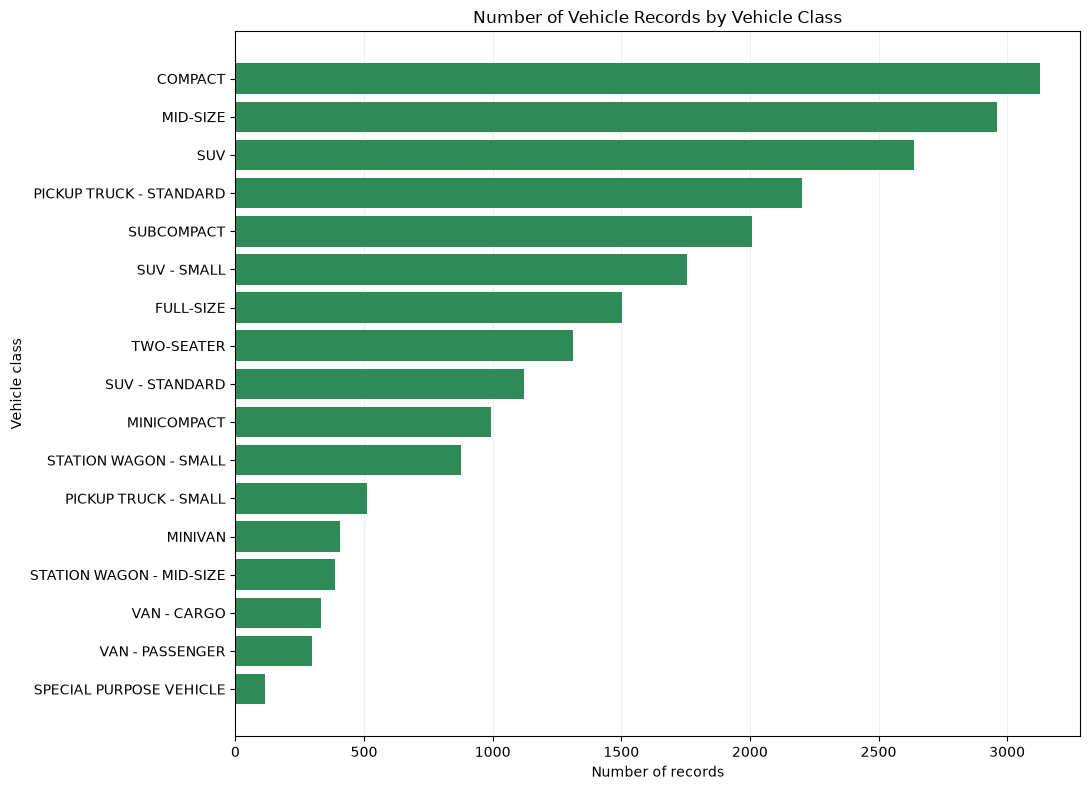

In [83]:
class_counts = class_summary["Records"].sort_values()

fig, ax = plt.subplots(figsize=(11, 8))

ax.barh(class_counts.index, class_counts.values, color="seagreen")

ax.set_title("Number of Vehicle Records by Vehicle Class")
ax.set_xlabel("Number of records")
ax.set_ylabel("Vehicle class")
ax.grid(axis="x", alpha=0.2)
ax.set_axisbelow(True)

fig.tight_layout()
fig.savefig(
    figures_dir / "04_records_by_class.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### 6.5 Average Fuel Consumption by Model Year
Explore how average combined consumption varies across model years.
These averages describe the records in the dataset, not actual fuel use by all drivers.

,Records,Mean
YEAR,,
2000,638,11.30
2001,679,11.20
2002,740,11.60
2003,820,11.47
2004,898,11.55
2005,1019,11.41
2006,968,11.28
2007,1043,11.42
2008,1079,11.26


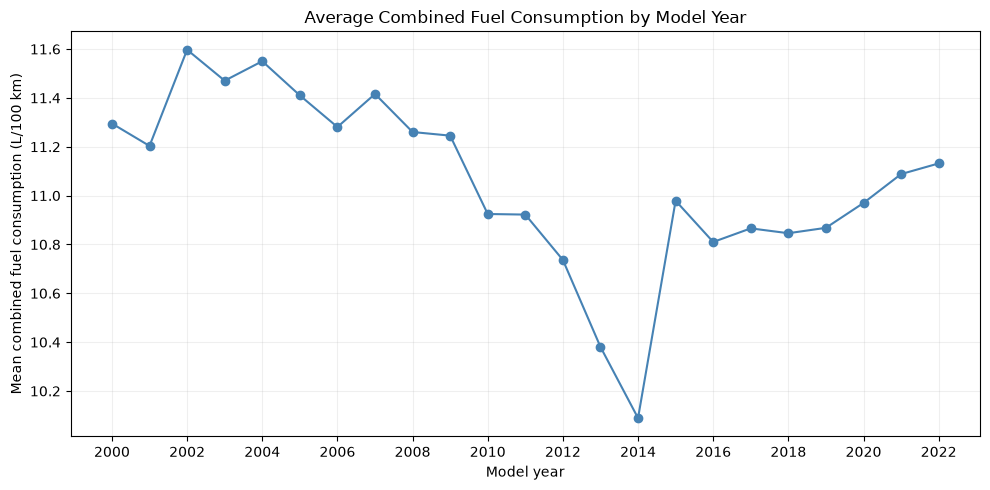

In [84]:
year_summary = (
    df_clean.groupby("YEAR")["COMB (L/100 km)"]
    .agg(Records="count", Mean="mean")
    .sort_index()
)

display(year_summary.round(2))
year_summary.to_csv("Model_Year_Summary.csv")

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    year_summary.index,
    year_summary["Mean"],
    marker="o",
    color="steelblue"
)

ax.set_title("Average Combined Fuel Consumption by Model Year")
ax.set_xlabel("Model year")
ax.set_ylabel("Mean combined fuel consumption (L/100 km)")
ax.set_xticks(range(2000, 2023, 2))
ax.grid(alpha=0.2)

fig.tight_layout()
fig.savefig(
    figures_dir / "05_consumption_by_year.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [85]:
print("Lowest average consumption:")
display(class_summary.head(3).round(2))

print("Highest average consumption:")
display(class_summary.tail(3).round(2))

print("Greatest variation within a vehicle class:")
display(
    class_summary.sort_values(
        "Standard_deviation", ascending=False
    ).head(3).round(2)
)

Lowest average consumption:


,Records,Mean,Median,Standard_deviation,Minimum,Maximum
VEHICLE CLASS,,,,,,
STATION WAGON - SMALL,877,8.74,8.7,1.46,4.6,15.0
COMPACT,3127,9.17,9.0,2.06,3.7,17.9
MID-SIZE,2960,9.75,9.6,2.40,3.8,20.0


Highest average consumption:


,Records,Mean,Median,Standard_deviation,Minimum,Maximum
VEHICLE CLASS,,,,,,
PICKUP TRUCK - STANDARD,2204,13.8,13.5,2.38,8.7,23.2
VAN - CARGO,332,15.5,14.6,2.34,11.3,20.4
VAN - PASSENGER,299,17.0,15.9,2.96,12.4,26.1


Greatest variation within a vehicle class:


,Records,Mean,Median,Standard_deviation,Minimum,Maximum
VEHICLE CLASS,,,,,,
TWO-SEATER,1312,11.84,11.1,3.49,3.6,26.1
VAN - PASSENGER,299,17.00,15.9,2.96,12.4,26.1
SUV,2639,12.08,11.7,2.70,6.1,23.2


## 7. Findings, Recommendations and Limitations

In [ ]:
import sys
import matplotlib

print("Python:", sys.version.split()[0])
print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("Matplotlib:", matplotlib.__version__)